# Fase 2: Análisis estadístico

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df_final = pd.read_csv("./files/df_final.csv")
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 403760 entries, 0 to 403759
Data columns (total 24 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   403760 non-null  int64  
 1   Loyalty Number               403760 non-null  int64  
 2   Year                         403760 non-null  int64  
 3   Month                        403760 non-null  int64  
 4   Flights Booked               403760 non-null  int64  
 5   Flights with Companions      403760 non-null  int64  
 6   Total Flights                403760 non-null  int64  
 7   Distance                     403760 non-null  int64  
 8   Points Accumulated           403760 non-null  float64
 9   Points Redeemed              403760 non-null  int64  
 10  Dollar Cost Points Redeemed  403760 non-null  int64  
 11  Country                      403760 non-null  str    
 12  Province                     403760 non-null  str    
 13  City      

### Variables numericas

In [11]:
df_final.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,403760.0,201879.500000,116555.616681,0.00,100939.75,201879.50,302819.25,403759.00
Loyalty Number,403760.0,549875.383713,258961.514684,100018.00,326699.00,550598.00,772152.00,999986.00
Year,403760.0,2017.500352,0.500000,2017.00,2017.00,2018.00,2018.00,2018.00
Month,403760.0,6.501335,3.451982,1.00,4.00,7.00,10.00,12.00
Flights Booked,403760.0,4.134050,5.230064,0.00,0.00,1.00,8.00,21.00
Flights with Companions,403760.0,1.036569,2.080472,0.00,0.00,0.00,1.00,11.00
Total Flights,403760.0,5.170619,6.526858,0.00,0.00,1.00,10.00,32.00
Distance,403760.0,1214.460979,1434.098521,0.00,0.00,525.00,2342.00,6293.00
Points Accumulated,403760.0,124.263761,146.696179,0.00,0.00,53.00,240.00,676.50
Points Redeemed,403760.0,30.838587,125.758002,0.00,0.00,0.00,0.00,876.00


In [6]:
# Creo una función para automatizar el análisis estadístico de una variable
# La función recibe dos parámetros: el DataFrame y la columna que quiero analizar
# Devuelve un nuevo DataFrame con estadísticas descriptivas principales

def resumen_analisis(df, columna):

    # Selecciono la columna elegida y elimino valores nulos (NaN)
    serie = df[columna].dropna()

    # Devuelvo un nuevo DataFrame con medidas estadísticas
    return pd.DataFrame({
        "media": [serie.mean()],          # promedio de los valores
        "mediana": [serie.median()],     # valor central de la distribución
        "std": [serie.std()],            # desviación estándar o dispersión
        "min": [serie.min()],            # valor mínimo
        "max": [serie.max()]             # valor máximo
    }).T                                # transpone filas y columnas

In [14]:
resumen_analisis(df_final,'Flights Booked')

,0
media,4.134050
mediana,1.000000
std,5.230064
min,0.000000
max,21.000000


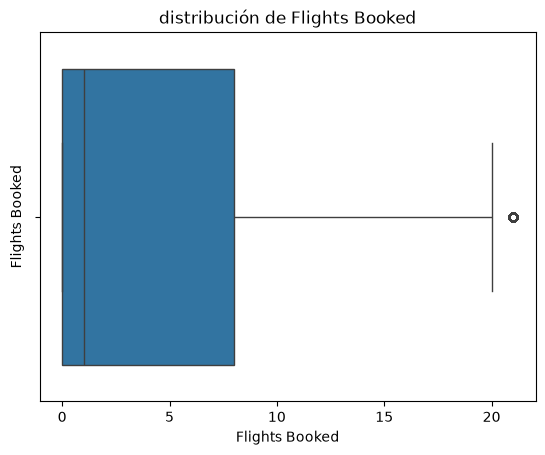

In [16]:
sns.boxplot(data=df_final, x='Flights Booked')
plt.title('distribución de Flights Booked')
plt.ylabel ('Flights Booked')
plt.show()

##### Análisis de Flights Booked:
- En promedio, los clientes registran aproximadamente 4 reservas de vuelo.
- La mediana nos indica que al menos el 50% de los registros tiene 1 reserva o menos.
- La desviacion estandar presenta una alta variabilidad siendo 5.23
- El minimo de cero nos dice que hay registros sin reservas
- El maximo al ser 21 indica que hay clientes con un alta actividad por lo que 

los Flights Booked presentan una distribucion asimetrica positiva

In [29]:
df_final["Year"].unique()

array([2017, 2018])

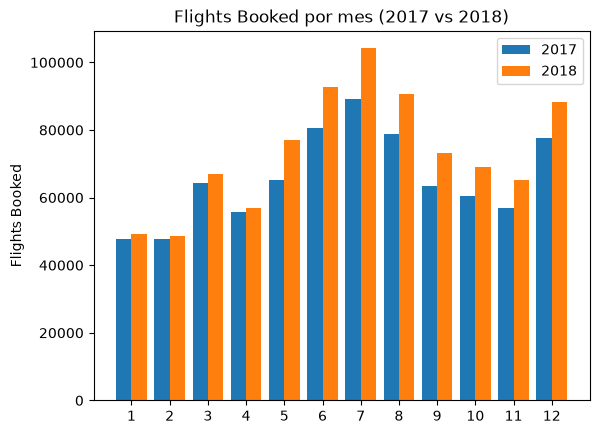

In [31]:
fig, ax = plt.subplots()

# agrupamos por año y mes
flights_per_month = df_final.groupby(
    ["Year", "Month"], 
    as_index=False
)["Flights Booked"].sum()

# separar cada año
datos_2017 = flights_per_month[flights_per_month["Year"] == 2017]
datos_2018 = flights_per_month[flights_per_month["Year"] == 2018]

# posiciones eje x
x = np.arange(len(datos_2017["Month"]))

# crear barras
ax.bar(x - width/2, datos_2017["Flights Booked"], width, label="2017")
ax.bar(x + width/2, datos_2018["Flights Booked"], width, label="2018")

# etiquetas
ax.set_xticks(x)
ax.set_xticklabels(datos_2017["Month"])

ax.set_ylabel("Flights Booked")
ax.set_title("Flights Booked por mes (2017 vs 2018)")
ax.legend()

plt.show()

In [15]:
resumen_analisis(df_final,'Flights with Companions')

,0
media,1.036569
mediana,0.000000
std,2.080472
min,0.000000
max,11.000000


In [32]:
(df_final["Flights with Companions"] == 0).mean() * 100

np.float64(73.06890231820884)

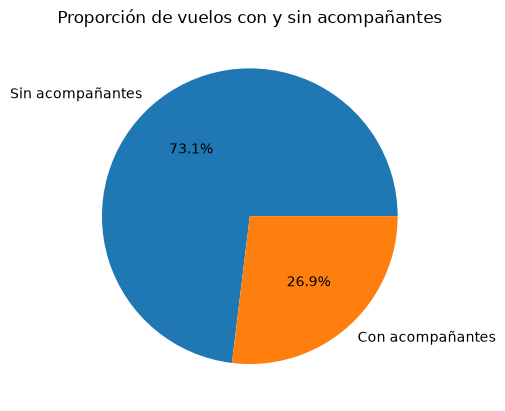

In [34]:
sin_acompanante = (df_final["Flights with Companions"] == 0).sum()
con_acompanante = (df_final["Flights with Companions"] > 0).sum()

plt.pie(
    [sin_acompanante, con_acompanante],
    labels=["Sin acompañantes", "Con acompañantes"],
    autopct="%1.1f%%"
)

plt.title("Proporción de vuelos con y sin acompañantes")

plt.show()

##### Análisis de Flights with Companions: 
- La mayoría de clientes no realiza vuelos acompañados, mientras una minoría concentra los valores más altos

In [35]:
resumen_analisis(df_final,'Total Flights')

,0
media,5.170619
mediana,1.000000
std,6.526858
min,0.000000
max,32.000000


##### Análisis de Total Flights: 
- Presenta una distribución asimétrica positiva, con una media de 5.17 vuelos frente a una mediana de 1. Esto indica que la mayoría de registros concentra valores bajos, mientras un grupo reducido de clientes presenta una actividad de vuelo significativamente mayor. La desviación estándar de 6.52 evidencia una elevada variabilidad en el comportamiento de viaje.

In [53]:
resumen_analisis(df_final,'Salary')

,0
media,79869.502477
mediana,74173.000000
std,32094.584140
min,9081.000000
max,407228.000000


##### Análisis de Salary: 
- El salario promedio de los clientes es de 79 mil al año
- La mitad de estos clientes gana 74 mil o menos
- Al tener una desviacion alta de 32, nos indica que los salarios estan bastante dispersos
- El salario minimo es de 9.081m frente al máximo de 407.228
Existen bastante variabilidad economica entre los clientes

In [51]:
resumen_analisis(df_final,'CLV')

,0
media,7990.864857
mediana,5776.340000
std,6863.317160
min,1898.010000
max,83325.380000


##### Análisis de CLV: 
- Muestra una gran diferencia en el valor económico de los clientes. Aunque el valor medio ronda los 8 mil, algunos clientes generan ingresos muy superiores, lo que aumenta la media. Esto indica que una parte pequeña de clientes tiene un peso económico mucho mayor dentro del negocio.

# Elegimos las columnas con valores categóricos son relevantes para el análisis.

In [59]:
columnas_categoricas = ["Gender", "Education", "Marital Status", "Loyalty Card", "Enrollment Type", "Province"]

for col in columnas_categoricas:
    print((df_final[col].value_counts(normalize=True) * 100).round(2))

Gender
Female    50.22
Male      49.78
Name: proportion, dtype: float64
Education
Bachelor                62.55
College                 25.33
High School or Below     4.68
Doctor                   4.39
Master                   3.04
Name: proportion, dtype: float64
Marital Status
Married     58.16
Single      26.79
Divorced    15.05
Name: proportion, dtype: float64
Loyalty Card
Star      45.51
Nova      33.90
Aurora    20.59
Name: proportion, dtype: float64
Enrollment Type
Standard          94.22
2018 Promotion     5.78
Name: proportion, dtype: float64
Province
Ontario                 32.26
British Columbia        26.36
Quebec                  19.71
Alberta                  5.79
Manitoba                 3.94
New Brunswick            3.80
Nova Scotia              3.10
Saskatchewan             2.44
Newfoundland             1.55
Yukon                    0.66
Prince Edward Island     0.39
Name: proportion, dtype: float64


Loyalty Card vs CLV

Pregunta: ¿Qué tipo de cliente aporta más valor?
Qué nivel de fidelización genera más dinero para la empresa.

In [64]:
df_final.groupby("Loyalty Card")["CLV"].mean()

Loyalty Card
Aurora    10673.621876
Nova       8046.609368
Star       6735.573925
Name: CLV, dtype: float64

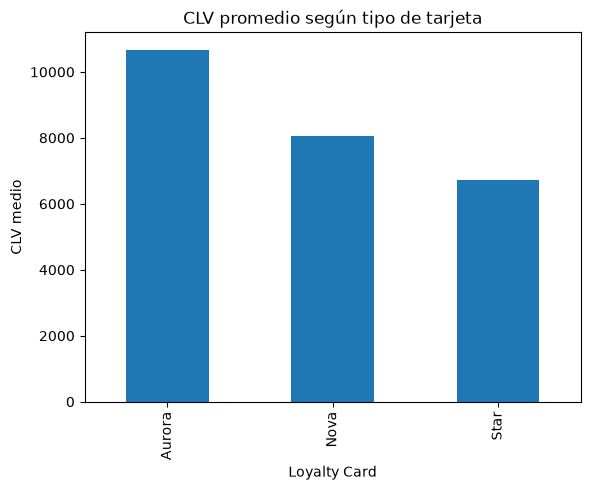

In [65]:
df_final.groupby("Loyalty Card")["CLV"].mean().plot(kind="bar")

plt.title("CLV promedio según tipo de tarjeta")
plt.ylabel("CLV medio")

plt.show()

- Se observa que:
Los clientes con tarjeta Aurora generan el mayor valor económico promedio para la empresa.

- Mientras que:
Los clientes con tarjeta Star presentan el menor valor promedio.

Marital Status vs Flights with Companions

Pregunta: ¿Quién viaja más acompañado?

In [66]:
df_final.groupby("Marital Status")["Flights with Companions"].mean()

Marital Status
Divorced    1.025131
Married     1.035981
Single      1.044271
Name: Flights with Companions, dtype: float64

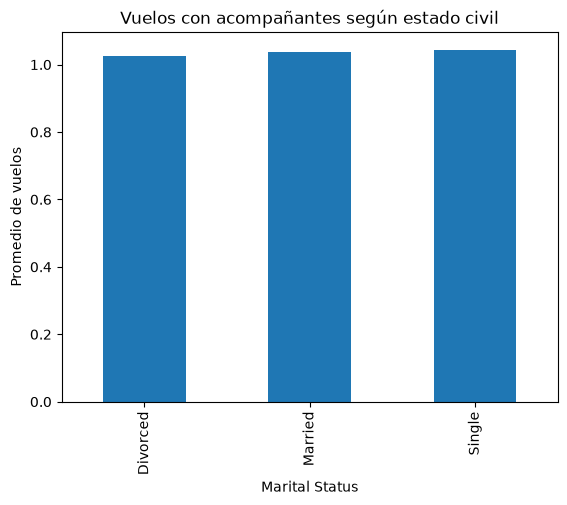

In [67]:
df_final.groupby("Marital Status")["Flights with Companions"].mean().plot(kind="bar")

plt.title("Vuelos con acompañantes según estado civil")
plt.ylabel("Promedio de vuelos")

plt.show()

- El estado civil no parece influir de manera significativa en la cantidad de vuelos realizados con acompañantes.